# ¿Se hereda la informalidad laboral en Paraguay?

**Data Science — Proyecto Integrador · Fase 1**

Isaac Ulises Gabriel González · Rubén David López · Martín Victorino Rodríguez

---

**Pregunta de investigación.** ¿La condición de informalidad laboral del jefe de hogar se asocia
con la informalidad laboral de los hijos e hijas ocupados de 18 a 29 años que conviven con él,
una vez controlados la edad, el sexo, el área de residencia y los años de estudio propios,
según los microdatos de la EPHC del período 2024–2026?

**Fuente.** Instituto Nacional de Estadística (INE) del Paraguay — Encuesta Permanente de Hogares
Continua (EPHC) trimestral, base REG02, Factor Revisión 2025.
Portal: https://www.ine.gov.py/microdatos/ · Descarga: 7 de septiembre de 2026.
Licencia de Uso de la Información Pública, Ley 5282/2014.

**Contenido.** Este cuaderno cubre las etapas 2 a 5 de la Fase 1 y produce todos los números y
gráficos del informe:

| Etapa | Contenido |
|---|---|
| 2 | Inventario de archivos, clave primaria, perfilado y evaluación de calidad |
| 3 | Limpieza, transformación y bitácora de decisiones |
| 4 | Análisis univariado y bivariado |
| 5 | Análisis exploratorio con nueve visualizaciones |

**Reproducibilidad.** Parte de los diez archivos `.SAV` originales y regenera el conjunto final
sin ninguna edición manual. Semilla fijada en 42.

## 0. Configuración del entorno

Este notebook funciona tanto en **Google Colab** como en **ejecución local**:
- En Colab, busca automáticamente una carpeta compartida en Google Drive.
- En local, usa la estructura de directorios estándar del proyecto (`data/`, `output/`, etc.).

**Requisitos previos (local):**
- Python 3.10+
- Instalar dependencias: `pip install -r requirements.txt`
- Archivos `.SAV` en la carpeta `data/raw/`

In [ ]:
import os
from pathlib import Path
import glob
import sys
import numpy as np
import pandas as pd

try:
    import pyreadstat
except ImportError:
    !pip install pyreadstat -q
    import pyreadstat

# =========================================================================
# 0. DETECCIÓN DEL ENTORNO (Colab vs Local)
# =========================================================================
def detectar_entorno():
    """Detecta automáticamente si se ejecuta en Colab o en local"""
    try:
        from google.colab import drive
        return "colab"
    except:
        return "local"

ENTORNO = detectar_entorno()
IN_COLAB = (ENTORNO == "colab")

print(f"Entorno detectado: {'Google Colab' if IN_COLAB else 'Local'}")
print(f"Python {sys.version.split()[0]} • Pandas {pd.__version__}")

# =========================================================================
# 1. CONFIGURACIÓN DE RUTAS SEGÚN EL ENTORNO
# =========================================================================
if IN_COLAB:
    # --- Google Colab ---
    print("\nMontando Google Drive para acceso colaborativo...")
    from google.colab import drive
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print(f"Advertencia al montar Drive: {e}")
    
    # Buscar carpeta compartida en Drive
    def buscar_carpeta_drive(nombre_carpeta):
        rutas_posibles = [
            Path('/content/drive/MyDrive') / nombre_carpeta,
            Path('/content/drive/Shared drives') / nombre_carpeta,
            Path('/content/drive') / nombre_carpeta,
        ]
        for ruta in rutas_posibles:
            if ruta.exists():
                return ruta
        # Búsqueda recursiva
        bases = [Path('/content/drive/MyDrive'), Path('/content/drive')]
        for base in bases:
            if base.exists():
                for candidato in base.glob(f'**/{nombre_carpeta}'):
                    if candidato.is_dir():
                        return candidato
        return None
    
    CARPETA_COMPARTIDA = 'datos_crudos_fase_1'
    ruta_drive = buscar_carpeta_drive(CARPETA_COMPARTIDA)
    
    if ruta_drive:
        INPUT_DIR = ruta_drive
        OUTPUT_DIR = Path('/content/drive/MyDrive/datos_limpios')
        print(f"✓ Carpeta compartida encontrada en Drive: {INPUT_DIR}")
    else:
        INPUT_DIR = Path('/content/datos_ephc')
        OUTPUT_DIR = Path('/content/datos_limpios')
        print(f"⚠ Usando almacenamiento local de sesión (Colab): {INPUT_DIR}")
        print(f"  Carga los archivos .SAV a {CARPETA_COMPARTIDA} en tu Drive para reproducibilidad total.")

else:
    # --- Entorno Local (Jupyter, VS Code, terminal) ---
    # Busca: data/raw/
    notebook_dir = Path('.').resolve()
    
    # Si el notebook está en /notebooks/, el raíz del proyecto está un nivel arriba
    if notebook_dir.name == 'notebooks':
        proyecto_dir = notebook_dir.parent
    else:
        proyecto_dir = notebook_dir
    
    INPUT_DIR = proyecto_dir / 'data' / 'raw'
    OUTPUT_DIR = proyecto_dir / 'output'
    
    print(f"\nEstructura local del proyecto:")
    print(f"  Raíz: {proyecto_dir}")
    print(f"  Datos crudos: {INPUT_DIR}")
    print(f"  Salida: {OUTPUT_DIR}")

# Asegurar que OUTPUT_DIR existe
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =========================================================================
# 2. BÚSQUEDA DE ARCHIVOS .SAV
# =========================================================================
archivos = sorted(glob.glob(str(INPUT_DIR / '*REG02*.SAV')))

if not archivos:
    raise FileNotFoundError(
        f'\n❌ No se encontraron archivos .SAV en {INPUT_DIR}\n'
        f'\nPARA CORREGIR:\n'
        f'• Local: Coloca los archivos .SAV en data/raw/ del proyecto\n'
        f'• Colab: Crea una carpeta "{CARPETA_COMPARTIDA}" en tu Google Drive y comparte con tus compañero/as.'
    )

print(f"\n✓ Se encontraron {len(archivos)} archivos .SAV")
for f in archivos[:3]:
    print(f"  · {Path(f).name}")
if len(archivos) > 3:
    print(f"  · ... y {len(archivos) - 3} más")

# =========================================================================
# 3. CONFIGURACIÓN GLOBAL Y FUNCIÓN AUXILIAR
# =========================================================================
SEMILLA = 42
np.random.seed(SEMILLA)
BITACORA = []

def registrar(paso, decision, afectados, fundamento):
    """Registra decisiones de limpieza en la bitácora"""
    BITACORA.append({
        'Paso': paso,
        'Decisión': decision,
        'Registros afectados': afectados,
        'Fundamento': fundamento,
    })
    print(f'[{paso}] {decision} → {afectados} registros')

Entorno detectado: Local
Python 3.12.3 • Pandas 3.0.6

Estructura local del proyecto:
  Raíz: /home/rubenlopez/Documentos/facu/9no Semestre/travascience/proyecto/ephc_reproducible
  Datos crudos: /home/rubenlopez/Documentos/facu/9no Semestre/travascience/proyecto/ephc_reproducible/data/raw
  Salida: /home/rubenlopez/Documentos/facu/9no Semestre/travascience/proyecto/ephc_reproducible/output

✓ Se encontraron 10 archivos .SAV
  · 44269-REG02_EPHC_3er Trim 2024.SAV
  · 54802-REG02_EPHC_1er Trim 2025.SAV
  · 6bf65-REG02_EPHC_3er Trim 2025.SAV
  · ... y 7 más


Librerías adicionales para las etapas 4 y 5.

In [2]:
import math
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, pearsonr, spearmanr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=0.95)
AZUL, NARANJA = "#1F4E79", "#E07A3F"
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

print("Librerías de análisis cargadas")

Librerías de análisis cargadas


---
# Etapa 2 — Comprensión y selección de los datos

## 2.1. Inventario de los archivos

Se descargaron diez trimestres consecutivos, del primero de 2024 al segundo de 2026, que es el
último publicado. Todos corresponden a la misma versión de los datos (Factor Revisión 2025).

La lectura se hace con `metadataonly=True`, que obtiene dimensiones y etiquetas sin cargar los
datos en memoria.

In [3]:
inventario = []
for ruta in archivos:
    _, meta = pyreadstat.read_sav(ruta, metadataonly=True)
    inventario.append({
        "Archivo": os.path.basename(ruta),
        "MB": round(os.path.getsize(ruta) / 1e6, 1),
        "Registros": meta.number_rows,
        "Variables": meta.number_columns,
    })

inv = pd.DataFrame(inventario)
display(inv)
print(f"Total: {inv.Registros.sum():,} registros · {inv.MB.sum():.1f} MB")

,Archivo,MB,Registros,Variables
0,44269-REG02_EPHC_3er Trim 2024.SAV,2.6,13353,154
1,54802-REG02_EPHC_1er Trim 2025.SAV,2.6,13246,154
2,6bf65-REG02_EPHC_3er Trim 2025.SAV,2.7,13536,154
3,75003-REG02_EPHC_4º Trim 2025.SAV,3.0,15555,154
4,84f1f-REG02_EPHC_1er Trim 2026.SAV,2.6,13059,154
5,b2b14-REG02_EPHC_2º Trim 2024.SAV,2.8,14081,154
6,c8ccc-REG02_EPHC_4º Trim 2024.SAV,3.2,16382,154
7,d6b15-REG02_EPHC_2º Trim 2026.SAV,2.6,13391,154
8,f7b48-REG02_EPHC_2º Trim 2025.SAV,2.7,13597,154
9,fb5f7-REG02_EPHC_1er_Trim_2024.SAV,2.7,13928,154


Total: 140,128 registros · 27.5 MB


**Compatibilidad estructural.** Antes de apilar hay que comprobar que los archivos comparten
las mismas variables. Si no fuera así, la concatenación produciría columnas con valores nulos
**sin emitir ningún error**.

In [4]:
conjuntos = {}
for ruta in archivos:
    _, meta = pyreadstat.read_sav(ruta, metadataonly=True)
    conjuntos[os.path.basename(ruta)] = set(meta.column_names)

comunes = set.intersection(*conjuntos.values())
union = set.union(*conjuntos.values())

print(f"Variables comunes a los {len(archivos)} archivos: {len(comunes)}")
print(f"Unión de variables: {len(union)}")
print(f"No presentes en todos: {sorted(union - comunes)}")

Variables comunes a los 10 archivos: 152
Unión de variables: 157
No presentes en todos: ['Añoest', 'FACTOR', 'Factor', 'añoest', 'factor']


**Hallazgo.** Las discrepancias no son variables distintas sino la **misma variable escrita con
distinta capitalización**: el factor de expansión aparece como `FACTOR`, `Factor` y `factor`, y
los años de estudio como `Añoest` y `añoest`, repartidos entre los archivos sin patrón aparente.

Es un problema serio y silencioso: apilar sin normalizar crearía columnas separadas y dejaría la
mitad de los valores del factor de expansión en nulo sin producir ningún mensaje de error. Todas
las estimaciones ponderadas saldrían mal sin que nada lo advirtiera. Por eso la Etapa 3 comienza
unificando los nombres a mayúsculas.

## 2.2. Diccionario de datos y perfilado

La cátedra no provee el diccionario: reconstruirlo forma parte de la evaluación. Se documentan
las 22 variables conservadas con su etiqueta original del INE, tipo detectado frente a tipo
correcto, unidad de medida, cardinalidad, rango o categorías observadas y porcentaje de
faltantes.

El perfilado se calcula sobre **los diez trimestres completos**, no sobre un archivo
representativo. Para que la lectura sea liviana se cargan únicamente las 22 columnas
seleccionadas mediante `usecols`.

In [5]:
SELECCION = ["UPM", "NVIVI", "NHOGA", "L02", "ANIO", "TRIMESTRE", "RONDA",
             "AREA", "ESTGEO", "P02", "P03", "P06", "AÑOEST", "PEAA", "INFORMALIDAD",
             "CATE_PEA", "RAMA_PEA", "TAMA_PEA", "B09A", "HORAB", "E01AIMDE", "FACTOR"]

# Lectura parcial de los diez trimestres: solo las columnas conservadas
partes_perfil, etiquetas, etiquetas_valor = [], {}, {}
for ruta in archivos:
    # usecols distingue mayúsculas y los nombres varían entre trimestres
    # (FACTOR/Factor/factor, Añoest/añoest): se resuelve el nombre real de cada archivo
    _, meta_n = pyreadstat.read_sav(ruta, metadataonly=True)
    reales = [c for c in meta_n.column_names if c.upper() in SELECCION]
    df_p, meta_p = pyreadstat.read_sav(ruta, usecols=reales)
    df_p.columns = [c.upper() for c in df_p.columns]
    partes_perfil.append(df_p)
    for nombre, etiqueta in meta_p.column_names_to_labels.items():
        etiquetas.setdefault(nombre.upper(), etiqueta)
    for nombre, vals in meta_p.variable_value_labels.items():
        etiquetas_valor.setdefault(nombre.upper(), vals)

perfil_base = pd.concat(partes_perfil, ignore_index=True)
print(f"Perfilado sobre {len(perfil_base):,} registros de {len(archivos)} trimestres")

# Metadatos definidos por el grupo: tipo correcto y unidad de medida
TIPO_UNIDAD = {
    "UPM": ("Entero", "código"), "NVIVI": ("Entero", "código"),
    "NHOGA": ("Entero", "código"), "L02": ("Entero", "código"),
    "ANIO": ("Entero", "año"), "TRIMESTRE": ("Entero", "código"),
    "RONDA": ("Categórica", "código"), "AREA": ("Binaria", "código"),
    "ESTGEO": ("Categórica", "código"), "P02": ("Entero", "años"),
    "P03": ("Categórica", "código"), "P06": ("Binaria", "código"),
    "AÑOEST": ("Entero", "años"), "PEAA": ("Categórica", "código"),
    "INFORMALIDAD": ("Binaria", "código"), "CATE_PEA": ("Categórica", "código"),
    "RAMA_PEA": ("Categórica", "código"), "TAMA_PEA": ("Categórica", "código"),
    "B09A": ("Entero", "años"), "HORAB": ("Entero", "horas/semana"),
    "E01AIMDE": ("Decimal", "Gs./mes"), "FACTOR": ("Decimal", "personas"),
}

def rango_observado(col):
    s = perfil_base[col].dropna()
    vals = etiquetas_valor.get(col)
    if vals and len(vals) <= 6:
        return " | ".join(f"{int(k)}={v}" for k, v in sorted(vals.items()))
    if vals:
        return f"{len(vals)} categorías etiquetadas"
    return f"{s.min():,.0f} a {s.max():,.0f}".replace(",", ".")

perfil = pd.DataFrame([{
    "Variable": c,
    "Etiqueta INE": (etiquetas.get(c) or "")[:42],
    "Tipo detectado": str(perfil_base[c].dtype),
    "Tipo correcto": TIPO_UNIDAD[c][0],
    "Unidad": TIPO_UNIDAD[c][1],
    "Cardinalidad": perfil_base[c].nunique(),
    "Rango o categorías observadas": rango_observado(c)[:48],
    "% faltantes": round(perfil_base[c].isna().mean() * 100, 1),
} for c in SELECCION]).set_index("Variable")

display(perfil)

Perfilado sobre 140,128 registros de 10 trimestres


,Etiqueta INE,Tipo detectado,Tipo correcto,Unidad,Cardinalidad,Rango o categorías observadas,% faltantes
Variable,,,,,,,
UPM,Unidad primaria de muestreo seleccionada,float64,Entero,código,1857,14 a 28.774,0.0
NVIVI,Número de orden de la vivienda seleccionad,float64,Entero,código,175,1 a 975,0.0
NHOGA,Número de orden del hogar dentro de la viv,float64,Entero,código,3,1 a 3,0.0
L02,Línea de la persona,float64,Entero,código,27,1 a 27,0.0
ANIO,Año de la Encuesta,float64,Entero,año,3,2022=Año 2022 | 2023=Año 2023 | 2024=Año 2024 |,0.0
TRIMESTRE,Trimestre,float64,Entero,código,10,20 categorías etiquetadas,0.0
RONDA,Ronda,float64,Categórica,código,2,1 a 2,0.0
AREA,AREA de Residencia,float64,Binaria,código,2,1=Urbana | 6=Rural,0.0
ESTGEO,Estratos Geográficos,float64,Categórica,código,31,31 categorías etiquetadas,0.0


**Tipo detectado frente a tipo correcto.** El lector de SPSS entrega **todas** las variables como
`float64`, incluidos los identificadores. Esa discrepancia no es cosmética: si `UPM` se concatena
como flotante, la clave resultante contiene `14.0` en lugar de `14` y deja de coincidir entre
trimestres. La conversión a entero se realiza en la Etapa 3.

## 2.4. Inventario de las 154 variables por bloque temático

El perfilado anterior cubre las 22 variables conservadas. Las 132 restantes se agrupan en bloques
temáticos para justificar su descarte, tal como exige el punto 6 de esta etapa.

In [ ]:
_, meta_full = pyreadstat.read_sav(archivos[-1], metadataonly=True)
todas = [c.upper() for c in meta_full.column_names]

def bloque(c):
    if c in SELECCION:
        return "CONSERVADAS"
    if c.startswith("C"):
        return "C — Ocupación secundaria"
    if c.startswith("A"):
        return "A — Actividad y búsqueda de empleo"
    if c.startswith("B"):
        return "B — Detalle de la ocupación principal"
    if c.startswith("D"):
        return "D — Ingresos no laborales"
    if c.startswith("E"):
        return "E — Ingresos agregados"
    return "Otras derivadas"

FUNDAMENTO = {
    "CONSERVADAS": "Clave, objetivo, controles y predictores",
    "B — Detalle de la ocupación principal": "Contiene B10 y B12, con que se construye el objetivo: circularidad",
    "C — Ocupación secundaria": "Sin poder discriminante (ver celda siguiente)",
    "A — Actividad y búsqueda de empleo": "Se aplica a desocupados e inactivos, no a nuestra población",
    "D — Ingresos no laborales": "Ingreso pasivo, ajeno a la condición laboral",
    "E — Ingresos agregados": "Colinealidad con E01AIMDE, que sí se conserva",
    "Otras derivadas": "Redundancia con PEAA",
}

# El porcentaje de faltantes se calcula, no se declara
completo, _ = pyreadstat.read_sav(archivos[-1])
completo.columns = [c.upper() for c in completo.columns]
falt_col = completo.isna().mean() * 100

bloques = pd.Series([bloque(c) for c in todas], index=todas).rename("Bloque").to_frame()
bloques["% faltantes"] = falt_col.reindex(bloques.index).values

resumen_bloques = bloques.groupby("Bloque").agg(
    Variables=("% faltantes", "size"),
    **{"% faltantes promedio": ("% faltantes", lambda x: round(x.mean(), 1))})
resumen_bloques["Fundamento del descarte"] = resumen_bloques.index.map(FUNDAMENTO)
display(resumen_bloques.sort_values("Variables", ascending=False))

print(f"Total: {len(todas)} variables · conservadas: {len(SELECCION)} · "
      f"descartadas: {len(todas) - len(SELECCION)}")
print(f"Base de cálculo: {os.path.basename(archivos[-1])} ({len(completo):,} registros)")

,Variables,% faltantes promedio,Fundamento del descarte
Bloque,,,
B — Detalle de la ocupación principal,50,71.6,"Contiene B10 y B12, con que se construye el ob..."
C — Ocupación secundaria,31,97.9,Sin poder discriminante (ver celda siguiente)
A — Actividad y búsqueda de empleo,27,71.1,"Se aplica a desocupados e inactivos, no a nues..."
CONSERVADAS,22,14.7,"Clave, objetivo, controles y predictores"
E — Ingresos agregados,13,0.0,"Colinealidad con E01AIMDE, que sí se conserva"
Otras derivadas,6,30.0,Redundancia con PEAA
D — Ingresos no laborales,5,74.8,"Ingreso pasivo, ajeno a la condición laboral"


Total: 154 variables · conservadas: 22 · descartadas: 132
Base de cálculo: fb5f7-REG02_EPHC_1er_Trim_2024.SAV (13,928 registros)


## 2.5. Evaluación de calidad: qué significan los faltantes

Antes de limpiar conviene entender qué significan los valores ausentes, porque determinan toda
la estrategia posterior.

In [ ]:
print("Etiquetas de la variable objetivo:")
print(etiquetas_valor.get("INFORMALIDAD", {}))

calidad = pd.DataFrame([
    {"Dimensión": "Completitud", "Evaluación": "Alta",
     "Evidencia": "Clave, P02, P03, P06, AREA, E01AIMDE y FACTOR sin faltantes"},
    {"Dimensión": "Consistencia", "Evaluación": "Alta",
     "Evidencia": f"Las {len(archivos)} fuentes comparten 154 variables; sin duplicados exactos"},
    {"Dimensión": "Exactitud aparente", "Evaluación": "Buena, con reservas",
     "Evidencia": "Códigos de no respuesta mínimos; ingresos atípicos imputados por el INE"},
    {"Dimensión": "Actualidad", "Evaluación": "Alta",
     "Evidencia": "Incluye el 2.º trimestre de 2026, último publicado"},
    {"Dimensión": "Trazabilidad", "Evaluación": "Total",
     "Evidencia": "Manual, cuestionario y diccionario publicados junto a los microdatos"},
]).set_index("Dimensión")
display(calidad)

Etiquetas de la variable objetivo:
{1.0: 'Ocupados informales no agropecuarios', 2.0: 'Ocupados formales no agropecuarios', 9.0: 'No Disponible'}


,Evaluación,Evidencia
Dimensión,,
Completitud,Alta,"Clave, P02, P03, P06, AREA, E01AIMDE y FACTOR ..."
Consistencia,Alta,Las 10 fuentes comparten 154 variables; sin du...
Exactitud aparente,"Buena, con reservas",Códigos de no respuesta mínimos; ingresos atíp...
Actualidad,Alta,"Incluye el 2.º trimestre de 2026, último publi..."
Trazabilidad,Total,"Manual, cuestionario y diccionario publicados ..."


**Lectura de los faltantes.** El 60 % de ausencia en `INFORMALIDAD` **no indica mala calidad del
dato**. El INE define esa variable solo para ocupados no agropecuarios, de modo que niños,
estudiantes, inactivos, desocupados y trabajadores agrícolas quedan legítimamente fuera de su
alcance. Lo mismo ocurre con `CATE_PEA`, `RAMA_PEA`, `TAMA_PEA`, `HORAB` y `B09A`.

Esta distinción entre **dato ausente** y **pregunta no aplicable** determina la estrategia de la
Etapa 3: se conserva la ausencia de forma explícita en lugar de imputarla.

## 2.6. Selección justificada

Se conservan 22 de las 154 variables. El descarte más relevante es el **bloque B** (detalle de la
ocupación principal), que contiene `B10` (aporta a una caja de jubilación) y `B12` (categoría en
la ocupación principal): son los componentes con los que el INE **construye la variable
objetivo**. Incorporarlos como predictores produciría un modelo circular, con desempeño casi
perfecto y valor explicativo nulo.

El descarte del bloque C (ocupación secundaria) se verifica empíricamente en lugar de
asumirse.

In [ ]:
verif, meta_v = pyreadstat.read_sav(archivos[-1], usecols=["Informalidad", "C01REC", "B10", "B12"])
verif.columns = [c.upper() for c in verif.columns]

ocupados = verif[verif.INFORMALIDAD.isin([1, 2])]
con_segunda = ocupados.C01REC.notna()

print(f"Ocupados con segunda ocupación: {con_segunda.mean():.1%}")
print("")
print("Tasa de informalidad según tenga o no segunda ocupación:")
print(ocupados.groupby(con_segunda).INFORMALIDAD
      .apply(lambda s: (s == 1).mean()).round(3).rename("tasa").to_string())

print("")
cols_c = [c for c in completo.columns if c.startswith("C") and c != "CATE_PEA"]
falt_c = completo.loc[completo.INFORMALIDAD.isin([1, 2]), cols_c].isna().mean().mean() * 100
print(f"Ausencia promedio del bloque C entre ocupados: {falt_c:.1f} % ({len(cols_c)} variables)")

print("")
print("Variables del bloque B que definen la variable objetivo:")
for nombre, etiqueta in meta_v.column_names_to_labels.items():
    if nombre.upper() in ("B10", "B12"):
        print(f"  {nombre}: {etiqueta}")

Ocupados con segunda ocupación: 10.7%

Tasa de informalidad según tenga o no segunda ocupación:
C01REC
False    0.671
True     0.585

Ausencia promedio del bloque C entre ocupados: 95.6 % (31 variables)

Variables del bloque B que definen la variable objetivo:
  B10: Aporta a una caja de jubilación
  B12: Categoría en Ocupación Principal


La segunda ocupación no aporta poder discriminante: la tasa de informalidad apenas se mueve
entre quienes la tienen y quienes no. Sumado a la ausencia promedio del bloque entre los ocupados
que acaba de calcularse, el descarte del bloque C queda justificado con evidencia y no por
suposición.

Las dos variables del bloque B que se imprimen arriba son la prueba del riesgo de circularidad:
la condición de informalidad del INE se construye a partir de ellas, de modo que usarlas como
predictores equivaldría a darle al modelo la respuesta.

---
# Etapa 3 — Limpieza y transformación

> **Regla no negociable:** toda transformación es reproducible por código desde los archivos
> originales. No se editó ningún dato en planilla de cálculo.

Cada decisión se registra en una bitácora con los registros afectados y su fundamento, mediante
la función `registrar()` definida en la celda de configuración.

## 1) Lectura y apilamiento de archivos .SAV

En esta etapa se leen los archivos `REG02_EPHC_*.SAV` del INE, se unifican los nombres de columnas y se combinan en un solo dataframe. La razón es que distintos trimestres pueden variar en mayúsculas/minúsculas de las columnas, y si no se normalizan se generan columnas duplicadas al concatenar.

In [6]:
archivos = sorted(glob.glob(str(INPUT_DIR / '*REG02*.SAV')))
if not archivos:
    raise FileNotFoundError(f'No se encontraron archivos REG02 en {INPUT_DIR}')

partes, renombres = [], 0
for ruta in archivos:
    df, _ = pyreadstat.read_sav(ruta)
    originales = list(df.columns)
    df.columns = [c.upper() for c in df.columns]
    renombres += sum(1 for a, b in zip(originales, df.columns) if a != b)
    df['ARCHIVO'] = os.path.basename(ruta)
    partes.append(df)

crudo = pd.concat(partes, ignore_index=True)
filas_iniciales = len(crudo)
registrar('3.4 Normalización', 'Nombres de columna unificados a mayúsculas', renombres, 'FACTOR/Factor/factor y Añoest/añoest varían entre trimestres; sin unificar, el apilamiento genera columnas duplicadas')
registrar('3.6 Integración', f'Apilamiento vertical de {len(archivos)} trimestres', filas_iniciales, 'Los archivos comparten estructura idéntica (154 variables); la unión es por concatenación, no por clave')
print(f'Cantidad final tras apilar: {len(crudo):,}')

[3.4 Normalización] Nombres de columna unificados a mayúsculas → 26 registros
[3.6 Integración] Apilamiento vertical de 10 trimestres → 140128 registros
Cantidad final tras apilar: 140,128


## 2) Claves y tipos

Los identificadores del INE vienen como flotantes en algunas lecturas. Para evitar errores de concatenación o claves duplicadas, se convierten a enteros y se crean identificadores de persona y hogar.

In [ ]:
for col in ['UPM', 'NVIVI', 'NHOGA', 'L02', 'ANIO', 'TRIMESTRE', 'RONDA']:
    crudo[col] = crudo[col].astype(int)
registrar('3.4 Normalización', 'Identificadores convertidos a entero', len(crudo), "Evita claves con decimales al concatenar ('14.0' vs '14')")

crudo['ID_PERSONA'] = (crudo.ANIO.astype(str) + '-' + crudo.TRIMESTRE.astype(str) + '-'
                      + crudo.UPM.astype(str) + '-' + crudo.NVIVI.astype(str) + '-'
                      + crudo.NHOGA.astype(str) + '-' + crudo.L02.astype(str))
crudo['ID_HOGAR'] = (crudo.ANIO.astype(str) + '-' + crudo.TRIMESTRE.astype(str) + '-'
                    + crudo.UPM.astype(str) + '-' + crudo.NVIVI.astype(str) + '-'
                    + crudo.NHOGA.astype(str))
assert crudo.ID_PERSONA.duplicated().sum() == 0, 'La clave primaria no es única'
registrar('3.2 Duplicados', 'Unicidad de la clave primaria verificada', len(crudo), 'ANIO+TRIMESTRE+UPM+NVIVI+NHOGA+L02 sin duplicados')

[3.4 Normalización] Identificadores convertidos a entero → 140128 registros
[3.2 Duplicados] Unicidad de la clave primaria verificada → 140128 registros


## 3) Duplicados exactos y códigos de no respuesta

Se eliminan filas duplicadas exactas. Además, el INE usa valores especiales (`99`, `999`, etc.) para representar ausencia de respuesta; estos se convierten a nulo para evitar distorsionar análisis descriptivos y estadísticos.

In [ ]:
dup_exactos = crudo.duplicated().sum()
crudo = crudo.drop_duplicates()
registrar('3.2 Duplicados', 'Verificación de duplicados exactos de fila', int(dup_exactos), 'No se detectaron filas idénticas')

CODIGOS_NR = {'P02': 999, 'AÑOEST': 99, 'PEAA': 9, 'INFORMALIDAD': 9, 'B09A': 99, 'HORAB': 999}
total_nr = 0
for col, codigo in CODIGOS_NR.items():
    n = int((crudo[col] == codigo).sum())
    crudo.loc[crudo[col] == codigo, col] = np.nan
    total_nr += n
registrar('3.3 Inconsistencias', 'Códigos de no respuesta convertidos a nulo', total_nr, 'El INE codifica la no respuesta como 99/999/9; tratarlos como números reales distorsionaría medias y rangos')

[3.2 Duplicados] Verificación de duplicados exactos de fila → 0 registros
[3.3 Inconsistencias] Códigos de no respuesta convertidos a nulo → 170 registros


## 4) Relación jefe/a y miembros del hogar

La unidad de interés es la relación entre jefe/a y miembros del hogar. Para eso, se identifica al jefe y luego se anexan sus atributos a los demás miembros del hogar.

In [ ]:
jefes = crudo[crudo.P03 == 1]
assert jefes.ID_HOGAR.duplicated().sum() == 0, 'Hay hogares con más de un jefe/a'
hogares_sin_jefe = crudo.ID_HOGAR.nunique() - len(jefes)
registrar('3.6 Integración', 'Auditoría de la tabla de jefes/as', len(jefes), f'Un jefe/a por hogar; hogares sin jefe: {hogares_sin_jefe}')

jefes_idx = jefes.set_index('ID_HOGAR')
crudo['JEFE_INFORMALIDAD'] = crudo.ID_HOGAR.map(jefes_idx['INFORMALIDAD'])
crudo['JEFE_AÑOEST'] = crudo.ID_HOGAR.map(jefes_idx['AÑOEST'])
crudo['JEFE_SEXO'] = crudo.ID_HOGAR.map(jefes_idx['P06'])
crudo['JEFE_EDAD'] = crudo.ID_HOGAR.map(jefes_idx['P02'])
no_apareados = crudo.JEFE_SEXO.isna().sum()
registrar('3.6 Integración', 'Unión izquierda persona → atributos del jefe/a', len(crudo), f'Registros sin jefe/a apareado: {no_apareados} ({100*no_apareados/len(crudo):.2f} %)')
crudo['TAM_HOGAR'] = crudo.groupby('ID_HOGAR')['L02'].transform('count')

[3.6 Integración] Auditoría de la tabla de jefes/as → 42512 registros
[3.6 Integración] Unión izquierda persona → atributos del jefe/a → 140128 registros


## 5) Filtro de la población de análisis

Se deja solo a los hijos/as del jefe/a, con una edad definida entre 18 y 29 años y con variable de informalidad observada. Esto define la población objetivo para el análisis posterior.

In [ ]:
paso = crudo[crudo.P03 == 3]
registrar('Filtrado', 'Se conservan hijos/as del jefe/a (P03 = 3)', len(paso), 'La unidad de análisis es el par jefe-hijo conviviente')

paso = paso[paso.P02.between(18, 29)]
registrar('Filtrado', 'Rango etario de 18 a 29 años', len(paso), '18 años es la edad mínima laboral plena; 29 acota la inserción laboral temprana y limita el sesgo por emancipación')

paso = paso[paso.INFORMALIDAD.isin([1, 2])]
registrar('Filtrado', 'Hijos/as con condición de informalidad definida', len(paso), 'La variable solo se define para ocupados no agropecuarios')

antes = len(paso)
paso = paso[paso.JEFE_INFORMALIDAD.isin([1, 2])]
registrar('Filtrado', 'Jefes/as con condición de informalidad definida', len(paso), f'Se excluyen {antes - len(paso)} pares cuyo jefe/a está desocupado, inactivo o es agropecuario; la comparación exige el dato en ambos')

[Filtrado] Se conservan hijos/as del jefe/a (P03 = 3) → 51613 registros
[Filtrado] Rango etario de 18 a 29 años → 13413 registros
[Filtrado] Hijos/as con condición de informalidad definida → 7906 registros
[Filtrado] Jefes/as con condición de informalidad definida → 5317 registros


## 6) Duplicados parciales y valores atípicos

También se valida la presencia de duplicados parciales por panel rotativo. Luego se corrigen condiciones imposibles como horas mayores a 112 y se revisan los ingresos para asegurar consistencia.

### Las tres estrategias evaluadas para el panel rotativo

La EPHC **repite deliberadamente** una parte de las viviendas entre trimestres, para poder medir
cambios. Al apilar diez trimestres, una misma persona puede aparecer más de una vez. No es un
error de los datos, pero implica que las observaciones no son independientes, supuesto que las
pruebas de la Fase 2 exigen verificar.

El grupo midió las tres alternativas posibles antes de decidir, en lugar de elegir por
conveniencia.

In [ ]:
def resumen_asociacion(x, nombre):
    ct = pd.crosstab(x.JEFE_INFORMALIDAD, x.INFORMALIDAD)
    chi2, p, _, _ = chi2_contingency(ct)
    odds = (ct.loc[1, 1] * ct.loc[2, 2]) / (ct.loc[1, 2] * ct.loc[2, 1])
    ee = math.sqrt(sum(1 / ct.values.flatten()))
    pond = lambda s: np.average((s.INFORMALIDAD == 1), weights=s.FACTOR)
    return {"Opción": nombre, "Casos": len(x),
            "Jefe/a informal": round(pond(x[x.JEFE_INFORMALIDAD == 1]), 3),
            "Jefe/a formal": round(pond(x[x.JEFE_INFORMALIDAD == 2]), 3),
            "Razón de momios": round(odds, 2),
            "IC 95 %": f"{math.exp(math.log(odds)-1.96*ee):.2f} – {math.exp(math.log(odds)+1.96*ee):.2f}"}

_tmp = paso.sort_values(["ANIO", "TRIMESTRE"])
comparacion = pd.DataFrame([
    resumen_asociacion(_tmp, "A) Todas las apariciones"),
    resumen_asociacion(_tmp.drop_duplicates(subset=["UPM","NVIVI","NHOGA","L02"], keep="first"),
                       "B) Primera aparición"),
    resumen_asociacion(_tmp[_tmp.RONDA == 1], "C) Solo ronda 1"),
])
comparacion["% de casos perdidos"] = (
    100 * (1 - comparacion.Casos / comparacion.Casos.max())).round(1)
display(comparacion)

,Opción,Casos,Jefe/a informal,Jefe/a formal,Razón de momios,IC 95 %,% de casos perdidos
0,A) Todas las apariciones,5317,0.718,0.582,1.86,1.65 – 2.09,0.0
1,B) Primera aparición,4482,0.734,0.594,1.87,1.64 – 2.14,15.7
2,C) Solo ronda 1,2642,0.725,0.594,1.94,1.64 – 2.30,50.3


**Decisión del grupo: opción B.** Ninguna alternativa modifica la conclusión —la razón de momios
se mueve entre 1,86 y 1,94 y los tres intervalos de confianza excluyen el valor 1—, lo que
constituye en sí mismo evidencia de robustez. Se elige B porque resuelve la dependencia entre
observaciones con un costo del 15,7 % de los casos, mientras que C descarta la mitad de la
muestra y ensancha el intervalo sin aportar garantías adicionales.

In [ ]:
CLAVE_PERSONA = ['UPM', 'NVIVI', 'NHOGA', 'L02']
paso = paso.sort_values(['ANIO', 'TRIMESTRE'])
repetidas = int(paso.duplicated(subset=CLAVE_PERSONA).sum())
paso = paso.drop_duplicates(subset=CLAVE_PERSONA, keep='first')
registrar('3.2 Duplicados', 'Se conserva la primera aparición de cada persona', repetidas, 'La EPHC repite viviendas entre trimestres (panel rotativo). Dos filas de la misma persona violan el supuesto de independencia exigido por las pruebas de la Fase 2. Decisión del grupo: opción B sobre tres evaluadas')

neg = int((paso.E01AIMDE < 0).sum())
registrar('3.3 Atípicos', 'Búsqueda de ingresos negativos', neg, 'No se detectaron importes imposibles')

horas_imp = int((paso.HORAB > 112).sum())
paso.loc[paso.HORAB > 112, 'HORAB'] = np.nan
registrar('3.3 Atípicos', 'Horas semanales superiores a 112 anuladas', horas_imp, '112 h = 16 h diarias durante 7 días; por encima es implausible')

ing_cero = int((paso.E01AIMDE == 0).sum())
registrar('3.3 Atípicos', 'Ocupados con ingreso declarado igual a cero', ing_cero, 'Se conservan: corresponden mayormente a trabajadores familiares no remunerados, categoría válida del mercado laboral')

registrar('3.3 Atípicos', 'Extremos de ingreso NO tratados como atípicos', 0, 'El manual del INE declara que los valores extremos fueron imputados por la mediana del grupo; no son observaciones reales y su recorte sería una intervención sobre un dato ya intervenido')

[3.2 Duplicados] Se conserva la primera aparición de cada persona → 835 registros
[3.3 Atípicos] Búsqueda de ingresos negativos → 0 registros
[3.3 Atípicos] Horas semanales superiores a 112 anuladas → 1 registros
[3.3 Atípicos] Ocupados con ingreso declarado igual a cero → 275 registros
[3.3 Atípicos] Extremos de ingreso NO tratados como atípicos → 0 registros


## 7) Valores faltantes y tratamiento de ausencias

Se elimina información ausente en la variable clave de educación y se conserva como categoría explícita lo que representa una no aplicabilidad estructural.

In [ ]:
faltantes = paso[['AÑOEST', 'JEFE_AÑOEST', 'HORAB', 'B09A', 'CATE_PEA', 'RAMA_PEA', 'TAMA_PEA']].isna().sum()
n_edu = int(paso.AÑOEST.isna().sum() + paso.JEFE_AÑOEST.isna().sum())
antes = len(paso)
paso = paso[paso.AÑOEST.notna() & paso.JEFE_AÑOEST.notna()]
registrar('3.1 Faltantes', 'Eliminación de casos sin años de estudio', antes - len(paso), f'Ausencia < 1 %, sin patrón identificable (MCAR). La educación es el control central del objetivo 3: imputarla alteraría justamente la variable que se quiere controlar')

registrar('3.1 Faltantes', 'Faltantes estructurales conservados como categoría', int(faltantes[['CATE_PEA', 'RAMA_PEA', 'TAMA_PEA']].sum()), 'No son datos ausentes sino preguntas no aplicables; se codifican como categoría explícita "No aplica" en lugar de imputarse')

for col in ['CATE_PEA', 'RAMA_PEA', 'TAMA_PEA']:
    paso[col] = paso[col].fillna(-1)

print(f'Cantidad de registros después del tratamiento de faltantes: {len(paso):,}')

[3.1 Faltantes] Eliminación de casos sin años de estudio → 2 registros
[3.1 Faltantes] Faltantes estructurales conservados como categoría → 0 registros
Cantidad de registros después del tratamiento de faltantes: 4,480


## 8) Variables derivadas

Aquí se construyen las variables binarias y categóricas que sirven para el análisis final: informalidad, educación, edad, departamento, ingreso por hora y otras variables de contexto.

In [ ]:
d = paso.copy()

d['informal'] = (d.INFORMALIDAD == 1).astype(int)
d['jefe_informal'] = (d.JEFE_INFORMALIDAD == 1).astype(int)
d['mujer'] = (d.P06 == 6).astype(int)
d['rural'] = (d.AREA == 6).astype(int)
d['jefa_mujer'] = (d.JEFE_SEXO == 6).astype(int)
d['edad'] = d.P02
d['educ_anios'] = d.AÑOEST
d['jefe_educ_anios'] = d.JEFE_AÑOEST

CORTES = [-1, 5, 9, 12, 30]
ETIQUETAS = ['Primaria incompleta (0-5)', 'EEB (6-9)', 'Media (10-12)', 'Superior (13+)']
d['educ_nivel'] = pd.cut(d.educ_anios, CORTES, labels=ETIQUETAS)
d['jefe_educ_nivel'] = pd.cut(d.jefe_educ_anios, CORTES, labels=ETIQUETAS)

d['edad_grupo'] = pd.cut(d.edad, [17, 21, 25, 29], labels=['18-21', '22-25', '26-29'])

DEPARTAMENTOS = {0: 'Asunción', 1: 'Concepción', 2: 'San Pedro', 3: 'Cordillera', 4: 'Guairá', 5: 'Caaguazú', 6: 'Caazapá', 7: 'Itapúa', 8: 'Misiones', 9: 'Paraguarí', 10: 'Alto Paraná', 11: 'Central', 12: 'Ñeembucú', 13: 'Amambay', 14: 'Canindeyú', 15: 'Pdte. Hayes'}
d['departamento'] = (d.ESTGEO // 10).map(DEPARTAMENTOS)

d['periodo'] = d.ANIO.astype(str) + '-T' + (d.TRIMESTRE - (d.ANIO - 2024) * 4 - 8).astype(str)
d['trimestre_orden'] = d.TRIMESTRE

d['ingreso_hora'] = np.where((d.HORAB > 0) & (d.E01AIMDE > 0), d.E01AIMDE / (d.HORAB * 4.33), np.nan)

d['ambos_informales'] = ((d.informal == 1) & (d.jefe_informal == 1)).astype(int)

registrar('3.5 Derivadas', 'Creación de 16 variables derivadas', len(d), 'Binarias del objetivo y controles; niveles educativos según la estructura del sistema paraguayo (EEB 9 años + Media 3); grupos de edad; departamento desde ESTGEO; período; ingreso por hora')
registrar('3.5 Derivadas', 'Deflactación de ingresos NO aplicada', 0, 'El proyecto no compara niveles de ingreso entre períodos; los montos se usan solo como descriptor dentro de cada trimestre')

[3.5 Derivadas] Creación de 16 variables derivadas → 4480 registros
[3.5 Derivadas] Deflactación de ingresos NO aplicada → 0 registros


## 9) Exportación del conjunto final

Finalmente se seleccionan las columnas relevantes, se renombran para mayor claridad y se exportan tanto el dataset limpio como la bitácora de decisiones.

In [ ]:
COLUMNAS = ['ID_PERSONA', 'ID_HOGAR', 'ANIO', 'TRIMESTRE', 'periodo', 'RONDA',
            'informal', 'jefe_informal', 'ambos_informales',
            'edad', 'edad_grupo', 'mujer', 'rural', 'departamento',
            'educ_anios', 'educ_nivel', 'jefe_educ_anios', 'jefe_educ_nivel',
            'jefa_mujer', 'JEFE_EDAD', 'TAM_HOGAR',
            'CATE_PEA', 'RAMA_PEA', 'TAMA_PEA', 'B09A', 'HORAB',
            'E01AIMDE', 'ingreso_hora', 'FACTOR']
final = d[COLUMNAS].rename(columns={'JEFE_EDAD': 'jefe_edad', 'TAM_HOGAR': 'tam_hogar',
                                  'CATE_PEA': 'categoria_ocup', 'RAMA_PEA': 'rama',
                                  'TAMA_PEA': 'tam_empresa', 'B09A': 'antiguedad',
                                  'HORAB': 'horas', 'E01AIMDE': 'ingreso',
                                  'FACTOR': 'factor', 'ANIO': 'anio',
                                  'TRIMESTRE': 'trimestre', 'RONDA': 'ronda'})

dataset_path = OUTPUT_DIR / 'dataset_limpio.csv'
bitacora_path = OUTPUT_DIR / 'bitacora_limpieza.csv'

final.to_csv(dataset_path, index=False, encoding='utf-8-sig')
pd.DataFrame(BITACORA).to_csv(bitacora_path, index=False, encoding='utf-8-sig')

print('\n' + '=' * 70)
print(f'Registros iniciales : {filas_iniciales:,}')
print(f'Registros finales   : {len(final):,}')
print(f'Variables finales   : {final.shape[1]}')
print(f'Tasa de informalidad: {np.average(final.informal, weights=final.factor):.3f}')
print('=' * 70)
print(f'Dataset guardado en: {dataset_path}')
print(f'Bitácora guardada en: {bitacora_path}')


Registros iniciales : 140,128
Registros finales   : 4,480
Variables finales   : 29
Tasa de informalidad: 0.678
Dataset guardado en: /content/drive/MyDrive/datos_limpios/dataset_limpio.csv
Bitácora guardada en: /content/drive/MyDrive/datos_limpios/bitacora_limpieza.csv


### Bitácora de limpieza

Las entradas que registran **decisiones de no intervenir** se incluyen deliberadamente: una
transformación evaluada y descartada es una decisión metodológica tan relevante como una
aplicada, y su omisión impediría reconstruir el criterio seguido.

In [ ]:
bitacora = pd.DataFrame(BITACORA)
display(bitacora)

,Paso,Decisión,Registros afectados,Fundamento
0,3.4 Normalización,Nombres de columna unificados a mayúsculas,26,FACTOR/Factor/factor y Añoest/añoest varían en...
1,3.6 Integración,Apilamiento vertical de 10 trimestres,140128,Los archivos comparten estructura idéntica (15...
2,3.4 Normalización,Identificadores convertidos a entero,140128,Evita claves con decimales al concatenar ('14....
3,3.2 Duplicados,Unicidad de la clave primaria verificada,140128,ANIO+TRIMESTRE+UPM+NVIVI+NHOGA+L02 sin duplicados
4,3.2 Duplicados,Verificación de duplicados exactos de fila,0,No se detectaron filas idénticas
5,3.3 Inconsistencias,Códigos de no respuesta convertidos a nulo,170,El INE codifica la no respuesta como 99/999/9;...
6,3.6 Integración,Auditoría de la tabla de jefes/as,42512,Un jefe/a por hogar; hogares sin jefe: 0
7,3.6 Integración,Unión izquierda persona → atributos del jefe/a,140128,Registros sin jefe/a apareado: 0 (0.00 %)
8,Filtrado,Se conservan hijos/as del jefe/a (P03 = 3),51613,La unidad de análisis es el par jefe-hijo conv...
9,Filtrado,Rango etario de 18 a 29 años,13413,18 años es la edad mínima laboral plena; 29 ac...


---
# Etapa 4 — Análisis univariado y bivariado

## 4.1. Variables numéricas

Estadísticos de posición, dispersión y forma para cada variable numérica del conjunto final.

In [ ]:
NUM = ["edad", "educ_anios", "jefe_educ_anios", "jefe_edad", "tam_hogar",
       "antiguedad", "horas", "ingreso", "ingreso_hora"]

filas = []
for c in NUM:
    s = final[c].dropna()
    filas.append({"Variable": c, "n": len(s), "Media": s.mean(), "Mediana": s.median(),
        "Moda": s.mode().iloc[0], "DE": s.std(), "CV %": 100 * s.std() / s.mean(),
        "Mín": s.min(), "Máx": s.max(), "P5": s.quantile(.05), "P25": s.quantile(.25),
        "P75": s.quantile(.75), "P95": s.quantile(.95),
        "RIC": s.quantile(.75) - s.quantile(.25),
        "Asimetría": stats.skew(s), "Curtosis": stats.kurtosis(s)})

univariado = pd.DataFrame(filas).set_index("Variable").round(2)
display(univariado)

,n,Media,Mediana,Moda,DE,CV %,Mín,Máx,P5,P25,P75,P95,RIC,Asimetría,Curtosis
Variable,,,,,,,,,,,,,,,
edad,4480,22.91,23.00,19.00,3.31,14.46,18.00,29.00,18.0,20.00,26.00,29.00,6.00,0.20,-1.09
educ_anios,4480,12.55,12.00,12.00,2.79,22.27,0.00,18.00,7.0,12.00,14.00,17.00,2.00,-0.77,1.71
jefe_educ_anios,4480,9.27,9.00,6.00,4.39,47.36,0.00,18.00,3.0,6.00,12.00,17.00,6.00,0.17,-0.89
jefe_edad,4480,52.05,52.00,52.00,7.79,14.96,32.00,83.00,40.0,46.00,57.00,65.00,11.00,0.32,-0.08
tam_hogar,4480,4.84,5.00,4.00,1.93,39.89,2.00,20.00,2.0,4.00,6.00,8.00,2.00,1.46,4.67
antiguedad,4479,2.19,1.00,0.00,2.65,120.77,0.00,20.00,0.0,0.00,3.00,8.00,3.00,1.81,4.28
horas,4479,43.23,45.00,48.00,15.01,34.72,2.00,112.00,15.0,36.00,50.00,68.00,14.00,-0.20,0.62
ingreso,4480,2291026.55,2400000.00,0.00,1757400.14,76.71,0.00,50000000.00,0.0,1280000.00,2908192.09,4702589.54,1628192.09,8.16,177.43
ingreso_hora,4204,14328.50,12269.05,11547.34,13374.17,93.34,640.08,307929.18,4202.0,8641.05,16037.98,30120.68,7396.93,9.16,138.31


## 4.2. Forma de las distribuciones

La pregunta relevante no es cuánto valen la asimetría y la curtosis, sino **si la media es un
resumen adecuado** de cada variable.

In [ ]:
for c in NUM:
    s = final[c].dropna()
    asim = stats.skew(s)
    veredicto = ("media adecuada" if abs(asim) < 0.5
                 else "preferir mediana" if abs(asim) < 2
                 else "MEDIA NO VÁLIDA")
    print(f"{c:18s} asimetría={asim:7.2f}  curtosis={stats.kurtosis(s):8.2f}  → {veredicto}")

edad               asimetría=   0.20  curtosis=   -1.09  → media adecuada
educ_anios         asimetría=  -0.77  curtosis=    1.71  → preferir mediana
jefe_educ_anios    asimetría=   0.17  curtosis=   -0.89  → media adecuada
jefe_edad          asimetría=   0.32  curtosis=   -0.08  → media adecuada
tam_hogar          asimetría=   1.46  curtosis=    4.67  → preferir mediana
antiguedad         asimetría=   1.81  curtosis=    4.28  → preferir mediana
horas              asimetría=  -0.20  curtosis=    0.62  → media adecuada
ingreso            asimetría=   8.16  curtosis=  177.43  → MEDIA NO VÁLIDA
ingreso_hora       asimetría=   9.16  curtosis=  138.31  → MEDIA NO VÁLIDA


El ingreso presenta una asimetría de 8,16 y una curtosis de 177: unos pocos valores muy altos
desplazan la media. **Todo el análisis de ingresos de este trabajo se basa en la mediana.**

Esto se relaciona con una limitación declarada por el productor: el manual del INE advierte que
los valores atípicos de ingreso fueron imputados por la mediana del grupo correspondiente, de
modo que los extremos no son plenamente interpretables como observaciones reales.

## 4.3. Variables categóricas y análisis de concentración

In [ ]:
CAT = ["educ_nivel", "jefe_educ_nivel", "edad_grupo", "departamento",
       "categoria_ocup", "rama", "tam_empresa"]

for c in CAT:
    v = final[c].value_counts()
    top = max(1, int(np.ceil(0.2 * len(v))))
    print(f"\n{c} — {len(v)} categorías")
    print(f"  Dominante: {v.index[0]} ({100 * v.iloc[0] / len(final):.1f} %)")
    print(f"  El 20 % de las categorías ({top}) explica el "
          f"{100 * v.head(top).sum() / len(final):.1f} % de los casos")


educ_nivel — 4 categorías
  Dominante: Media (10-12) (46.5 %)
  El 20 % de las categorías (1) explica el 46.5 % de los casos

jefe_educ_nivel — 4 categorías
  Dominante: EEB (6-9) (40.4 %)
  El 20 % de las categorías (1) explica el 40.4 % de los casos

edad_grupo — 3 categorías
  Dominante: 18-21 (39.1 %)
  El 20 % de las categorías (1) explica el 39.1 % de los casos

departamento — 16 categorías
  Dominante: Central (27.7 %)
  El 20 % de las categorías (4) explica el 57.3 % de los casos

categoria_ocup — 6 categorías
  Dominante: 2.0 (67.4 %)
  El 20 % de las categorías (2) explica el 80.8 % de los casos

rama — 7 categorías
  Dominante: 5.0 (39.8 %)
  El 20 % de las categorías (2) explica el 63.8 % de los casos

tam_empresa — 11 categorías
  Dominante: 2.0 (34.5 %)
  El 20 % de las categorías (3) explica el 58.6 % de los casos


La concentración es alta en las variables laborales: dos categorías ocupacionales reúnen el
80,8 % de los casos. Esto condiciona el modelado de la Fase 3, donde las categorías poco
frecuentes deberán agruparse para evitar celdas con muy pocos casos.

## 4.4. Bivariado: categórica frente a categórica

Se reporta la **V de Cramér junto al valor p**. Con una muestra de este tamaño casi cualquier
diferencia resulta significativa, de modo que el tamaño del efecto es lo que indica si la
asociación importa en términos prácticos.

In [ ]:
def v_cramer(a, b):
    ct = pd.crosstab(a, b)
    chi2, p, _, _ = chi2_contingency(ct)
    return math.sqrt(chi2 / ct.values.sum()), chi2, p

filas = []
for c in ["jefe_informal", "jefe_educ_nivel", "educ_nivel", "edad_grupo", "mujer",
          "rural", "departamento", "categoria_ocup", "rama", "tam_empresa", "jefa_mujer"]:
    v, chi2, p = v_cramer(final[c], final.informal)
    intensidad = ("Fuerte" if v >= 0.5 else "Moderada" if v >= 0.2
                  else "Débil" if v >= 0.1 else "Nula")
    filas.append({"Variable": c, "Chi-cuadrado": round(chi2, 1), "Valor p": f"{p:.1e}",
                  "V de Cramér": round(v, 3), "Intensidad": intensidad})

display(pd.DataFrame(filas).sort_values("V de Cramér", ascending=False).reset_index(drop=True))

,Variable,Chi-cuadrado,Valor p,V de Cramér,Intensidad
0,tam_empresa,1242.5,9.5e-261,0.527,Fuerte
1,categoria_ocup,395.1,3.5e-83,0.297,Moderada
2,departamento,271.8,3.9e-49,0.246,Moderada
3,educ_nivel,260.4,3.7e-56,0.241,Moderada
4,rama,211.9,5.5e-43,0.217,Moderada
5,edad_grupo,138.7,7.7e-31,0.176,Débil
6,jefe_educ_nivel,119.6,9.3e-26,0.163,Débil
7,jefe_informal,88.4,5.3e-21,0.140,Débil
8,rural,52.4,4.5e-13,0.108,Débil
9,jefa_mujer,0.3,5.7e-01,0.009,Nula


**Resultado central del análisis exploratorio.** El tamaño del establecimiento se asocia a la
informalidad con una intensidad casi **cuatro veces mayor** que la condición del jefe/a de hogar.
La estructura productiva donde la persona consigue empleo pesa más que su hogar de origen.

Segundo hallazgo: dentro de los atributos del jefe/a, su **nivel educativo discrimina más** que
su condición de formalidad, lo que abre la posibilidad de que el canal de transmisión sea
educativo antes que ocupacional.

Tercer hallazgo, contraintuitivo: **el sexo no muestra asociación alguna** con la informalidad.

### Tabla de contingencia de la relación central

In [ ]:
ct = pd.crosstab(final.jefe_informal, final.informal, margins=True)
ct.index = ["Jefe/a formal", "Jefe/a informal", "Total"]
ct.columns = ["Hijo/a formal", "Hijo/a informal", "Total"]
print("Frecuencias absolutas:")
display(ct)

print("Porcentajes por fila:")
display((pd.crosstab(final.jefe_informal, final.informal, normalize="index") * 100).round(1))

print("Porcentajes por columna:")
display((pd.crosstab(final.jefe_informal, final.informal, normalize="columns") * 100).round(1))

Frecuencias absolutas:


,Hijo/a formal,Hijo/a informal,Total
Jefe/a formal,640,1078,1718
Jefe/a informal,665,2097,2762
Total,1305,3175,4480


Porcentajes por fila:


informal,0,1
jefe_informal,,
0,37.3,62.7
1,24.1,75.9


Porcentajes por columna:


informal,0,1
jefe_informal,,
0,49.0,34.0
1,51.0,66.0


## 4.5. Bivariado: numérica frente a numérica

In [ ]:
dd = final[NUM].dropna()
pares = [("educ_anios", "jefe_educ_anios"), ("ingreso", "horas"), ("ingreso", "educ_anios"),
         ("ingreso", "antiguedad"), ("ingreso_hora", "horas"), ("edad", "jefe_edad")]

for a, b in pares:
    print(f"{a:16s} vs {b:16s}  Pearson r={pearsonr(dd[a], dd[b])[0]:6.3f} · "
          f"Spearman rho={spearmanr(dd[a], dd[b])[0]:6.3f}")

educ_anios       vs jefe_educ_anios   Pearson r= 0.404 · Spearman rho= 0.392
ingreso          vs horas             Pearson r= 0.239 · Spearman rho= 0.323
ingreso          vs educ_anios        Pearson r= 0.240 · Spearman rho= 0.268
ingreso          vs antiguedad        Pearson r= 0.069 · Spearman rho= 0.083
ingreso_hora     vs horas             Pearson r=-0.292 · Spearman rho=-0.285
edad             vs jefe_edad         Pearson r= 0.421 · Spearman rho= 0.427


## 4.6. Bivariado: numérica frente a categórica

Se usa la **U de Mann-Whitney** en lugar de la prueba t porque la fuerte asimetría de las
variables de ingreso desaconseja comparar medias.

In [ ]:
for c in ["ingreso", "ingreso_hora", "horas", "educ_anios",
          "jefe_educ_anios", "antiguedad", "edad"]:
    a = final[final.informal == 1][c].dropna()
    b = final[final.informal == 0][c].dropna()
    u, p = mannwhitneyu(a, b)
    dif = 100 * (a.median() - b.median()) / b.median() if b.median() else np.nan
    print(f"{c:16s} informal={a.median():12,.0f} | formal={b.median():12,.0f} "
          f"| dif={dif:6.1f} % | p={p:.1e}")

ingreso          informal=   1,801,293 | formal=   2,908,192 | dif= -38.1 % | p=2.4e-257
ingreso_hora     informal=      10,659 | formal=      14,665 | dif= -27.3 % | p=2.1e-136
horas            informal=          45 | formal=          48 | dif=  -6.2 % | p=9.9e-17
educ_anios       informal=          12 | formal=          13 | dif=  -7.7 % | p=7.4e-69
jefe_educ_anios  informal=           8 | formal=          12 | dif= -33.3 % | p=1.2e-30
antiguedad       informal=           1 | formal=           2 | dif= -50.0 % | p=1.2e-03
edad             informal=          22 | formal=          24 | dif=  -8.3 % | p=2.0e-35


La brecha de ingreso mensual (−38,1 %) se reduce a −27,3 % al medirla por hora trabajada: una
parte de la diferencia proviene de jornadas más cortas y el resto de una remuneración horaria
efectivamente menor.

---
# Etapa 5 — Análisis descriptivo y exploratorio

Nueve visualizaciones, cada una con título descriptivo, ejes rotulados con unidades e
interpretación escrita inmediatamente debajo.

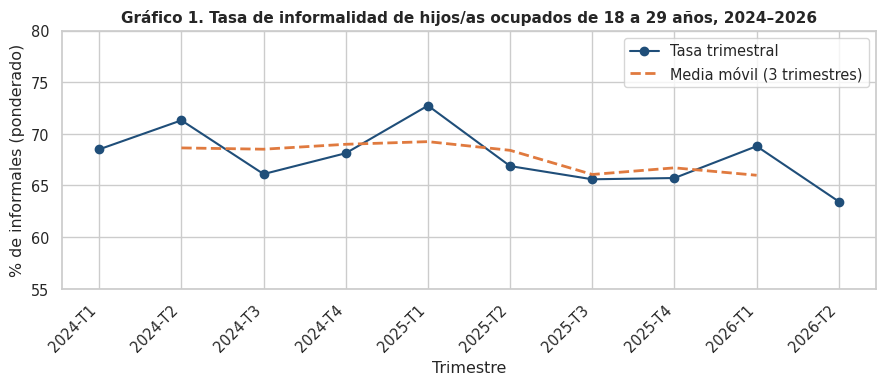

Valores representados (%):


,tasa,mm3
periodo,,
2024-T1,68.5,NaN
2024-T2,71.3,68.6
2024-T3,66.1,68.5
2024-T4,68.1,69.0
2025-T1,72.7,69.2
2025-T2,66.9,68.4
2025-T3,65.6,66.1
2025-T4,65.7,66.7
2026-T1,68.8,66.0


Mínimo: 63.4 %  ·  Máximo: 72.7 %  ·  Media móvil entre 66.0 % y 69.2 %


In [ ]:
W = lambda x, c="informal": np.average(x[c], weights=x.factor)

g = final.groupby("periodo").apply(lambda x: W(x)).rename("tasa").to_frame()
g["mm3"] = g.tasa.rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(g.index, g.tasa * 100, "o-", color=AZUL, label="Tasa trimestral")
ax.plot(g.index, g.mm3 * 100, "--", color=NARANJA, lw=2, label="Media móvil (3 trimestres)")
ax.set_title("Gráfico 1. Tasa de informalidad de hijos/as ocupados de 18 a 29 años, 2024–2026",
             fontsize=11, weight="bold")
ax.set_xlabel("Trimestre"); ax.set_ylabel("% de informales (ponderado)"); ax.set_ylim(55, 80)
ax.legend(); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

print("Valores representados (%):")
display((g * 100).round(1))
print(f"Mínimo: {g.tasa.min()*100:.1f} %  ·  Máximo: {g.tasa.max()*100:.1f} %  ·  "
      f"Media móvil entre {g.mm3.min()*100:.1f} % y {g.mm3.max()*100:.1f} %")

**Interpretación.** La tasa oscila entre 63,4 % y 72,7 % sin tendencia definida: la media móvil
se mantiene entre 66,0 % y 69,2 %. El descenso del primer al último trimestre es del mismo orden que
la variación trimestral ordinaria y no constituye un quiebre. La conclusión relevante es la
**estabilidad**: la informalidad juvenil no mejoró ni empeoró de forma apreciable en dos años y
medio, lo que sugiere un fenómeno estructural antes que coyuntural.

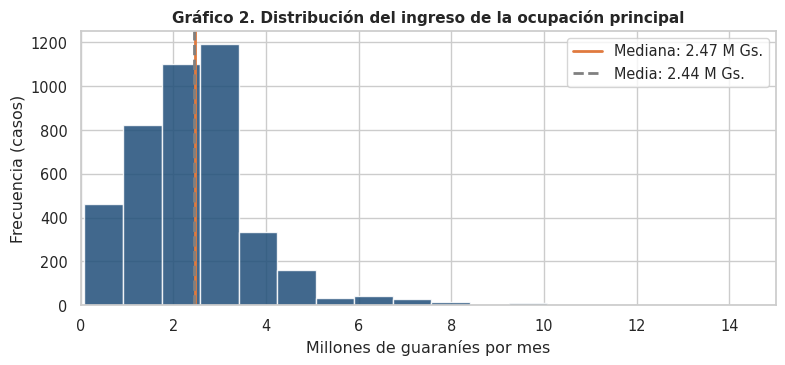

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.8))
s = final[final.ingreso > 0].ingreso / 1e6
ax.hist(s, bins=60, color=AZUL, alpha=.85)
ax.axvline(s.median(), color=NARANJA, lw=2, label=f"Mediana: {s.median():.2f} M Gs.")
ax.axvline(s.mean(), color="gray", lw=2, ls="--", label=f"Media: {s.mean():.2f} M Gs.")
ax.set_xlim(0, 15)
ax.set_title("Gráfico 2. Distribución del ingreso de la ocupación principal",
             fontsize=11, weight="bold")
ax.set_xlabel("Millones de guaraníes por mes"); ax.set_ylabel("Frecuencia (casos)")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretación.** Distribución unimodal con cola derecha muy prolongada. El pico en cero
corresponde a los trabajadores familiares no remunerados, que arrastran la media hacia abajo,
mientras los ingresos extremos la empujan hacia arriba. Con una asimetría de 8,16, toda
inferencia sobre ingresos debe basarse en la mediana.

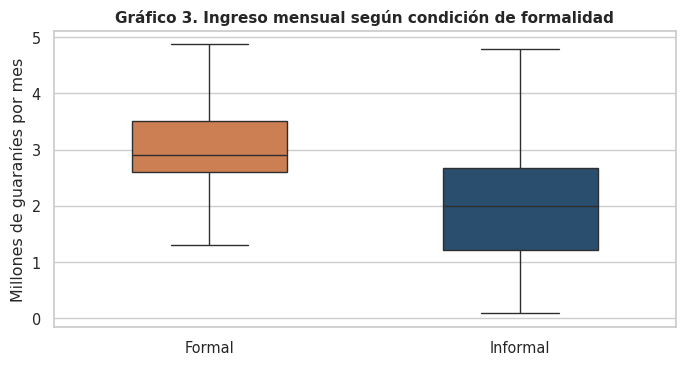

Mediana de ingreso, excluyendo ingresos cero (Gs./mes):
cond
Formal      2908192.0
Informal    2000000.0
Brecha en este gráfico: -31.2 %
(la tabla 4.6 incluye los ingresos cero y arroja una brecha mayor)


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.8))
dd_box = final[final.ingreso > 0].copy()
dd_box["cond"] = dd_box.informal.map({1: "Informal", 0: "Formal"})
sns.boxplot(data=dd_box, x="cond", y=dd_box.ingreso / 1e6, ax=ax, hue="cond",
            palette=[NARANJA, AZUL], showfliers=False, width=.5, legend=False)
ax.set_title("Gráfico 3. Ingreso mensual según condición de formalidad",
             fontsize=11, weight="bold")
ax.set_xlabel(""); ax.set_ylabel("Millones de guaraníes por mes")
plt.tight_layout(); plt.show()

print("Mediana de ingreso, excluyendo ingresos cero (Gs./mes):")
med = dd_box.groupby("cond").ingreso.median()
print(med.round(0).to_string())
print(f"Brecha en este gráfico: {100*(med['Informal']-med['Formal'])/med['Formal']:.1f} %")
print("(la tabla 4.6 incluye los ingresos cero y arroja una brecha mayor)")

**Interpretación.** Las cajas se solapan parcialmente pero la diferencia de medianas es clara:
2,00 millones frente a 2,91 millones de guaraníes, según los valores impresos bajo el gráfico.

Conviene advertir una diferencia con la tabla de la sección 4.6, donde la mediana de los
informales es de 1,80 millones: **este gráfico excluye los ingresos declarados en cero**, es
decir a los trabajadores familiares no remunerados, porque un cero no es interpretable en una
escala de remuneración. Al excluirlos, la mediana de los informales sube, y la brecha se estrecha
de 38,1 % a 31,2 %. Ambos cálculos son correctos; lo que cambia es el denominador, y por eso se
declara.

La caja de los informales es más ancha en su mitad inferior: la precariedad no solo baja el
ingreso sino que lo vuelve más disperso hacia abajo.

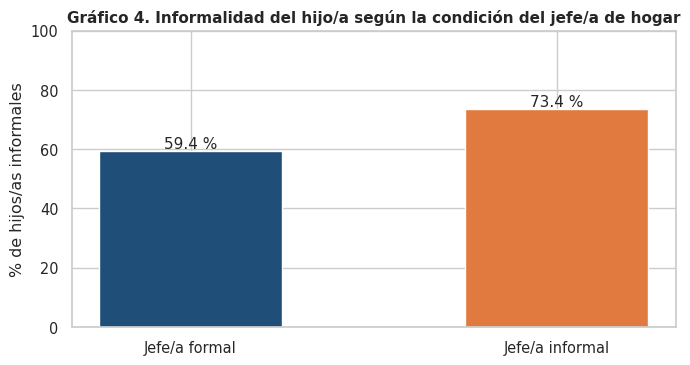

Jefe/a formal  : 59.4 %
Jefe/a informal: 73.4 %
Brecha         : 14.0 puntos porcentuales


In [ ]:
fig, ax = plt.subplots(figsize=(7, 3.8))
vals = [W(final[final.jefe_informal == 0]) * 100, W(final[final.jefe_informal == 1]) * 100]
b = ax.bar(["Jefe/a formal", "Jefe/a informal"], vals, color=[AZUL, NARANJA], width=.5)
ax.bar_label(b, fmt="%.1f %%", fontsize=11)
ax.set_ylim(0, 100); ax.set_ylabel("% de hijos/as informales")
ax.set_title("Gráfico 4. Informalidad del hijo/a según la condición del jefe/a de hogar",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

print(f"Jefe/a formal  : {vals[0]:.1f} %")
print(f"Jefe/a informal: {vals[1]:.1f} %")
print(f"Brecha         : {vals[1] - vals[0]:.1f} puntos porcentuales")

**Interpretación.** La relación central del proyecto: 73,4 % frente a 59,4 %, una brecha de 14
puntos porcentuales. Obsérvese que **incluso el grupo favorecido supera el 59 %** de
informalidad, lo que recuerda que se trata de un fenómeno mayoritario en toda la población
joven, no de una condición reservada a los hogares precarios.

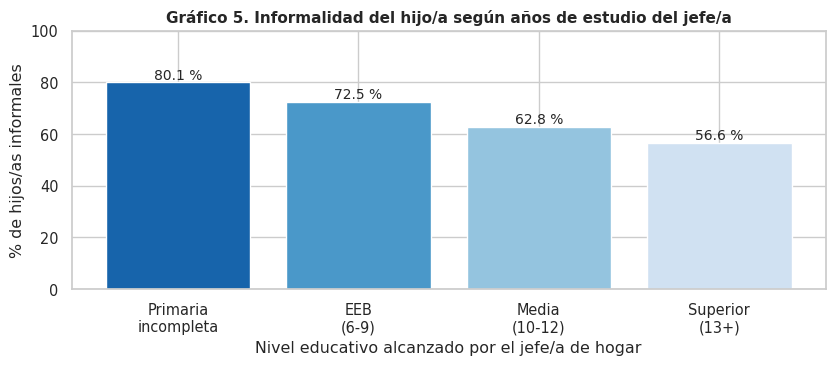

  Primaria incompleta (0-5)     80.1 %
  EEB (6-9)                     72.5 %
  Media (10-12)                 62.8 %
  Superior (13+)                56.6 %
Amplitud del gradiente: 23.4 puntos porcentuales
Medias de años de estudio → hijo/a: 12.6 · jefe/a: 9.3


In [ ]:
orden = ["Primaria incompleta (0-5)", "EEB (6-9)", "Media (10-12)", "Superior (13+)"]
vals = [W(final[final.jefe_educ_nivel == x]) * 100 for x in orden]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
b = ax.bar(range(4), vals, color=sns.color_palette("Blues_r", 4))
ax.bar_label(b, fmt="%.1f %%", fontsize=10)
ax.set_xticks(range(4))
ax.set_xticklabels(["Primaria\nincompleta", "EEB\n(6-9)", "Media\n(10-12)", "Superior\n(13+)"])
ax.set_ylim(0, 100); ax.set_ylabel("% de hijos/as informales")
ax.set_xlabel("Nivel educativo alcanzado por el jefe/a de hogar")
ax.set_title("Gráfico 5. Informalidad del hijo/a según años de estudio del jefe/a",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

for nivel, valor in zip(orden, vals):
    print(f"  {nivel:28s} {valor:5.1f} %")
print(f"Amplitud del gradiente: {vals[0] - vals[-1]:.1f} puntos porcentuales")
print(f"Medias de años de estudio → hijo/a: {final.educ_anios.mean():.1f} · "
      f"jefe/a: {final.jefe_educ_anios.mean():.1f}")

**Interpretación.** El gradiente es monótono y desciende 23,4 puntos entre los extremos: 80,1 %
cuando el jefe/a no completó la primaria y 56,6 % cuando alcanzó estudios superiores. La
educación del jefe/a discrimina **más** que su condición laboral (V de Cramér 0,163 frente a
0,140), lo que sugiere que el canal educativo del hogar podría ser más determinante que el
ocupacional.

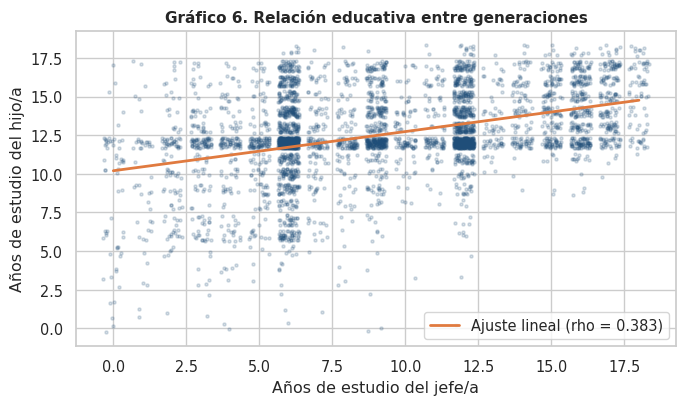

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.2))
jitter = lambda s: s + np.random.uniform(-.35, .35, len(s))
ax.scatter(jitter(final.jefe_educ_anios), jitter(final.educ_anios), s=5, alpha=.18, color=AZUL)
z = np.polyfit(final.jefe_educ_anios, final.educ_anios, 1)
x = np.linspace(0, 18, 10)
rho = spearmanr(final.jefe_educ_anios, final.educ_anios)[0]
ax.plot(x, np.polyval(z, x), color=NARANJA, lw=2, label=f"Ajuste lineal (rho = {rho:.3f})")
ax.set_xlabel("Años de estudio del jefe/a"); ax.set_ylabel("Años de estudio del hijo/a")
ax.set_title("Gráfico 6. Relación educativa entre generaciones", fontsize=11, weight="bold")
ax.legend(); plt.tight_layout(); plt.show()

**Interpretación.** Asociación positiva moderada. Se observa un techo en 18 años y una
acumulación en los 12 años del hijo/a (secundaria completa). La dispersión vertical sobre cada
valor del eje horizontal es amplia: la educación del jefe/a **condiciona pero no determina** la
del hijo/a. Hay movilidad educativa ascendente evidente: la media del hijo/a es 12,6 años frente
a 9,3 del jefe/a.

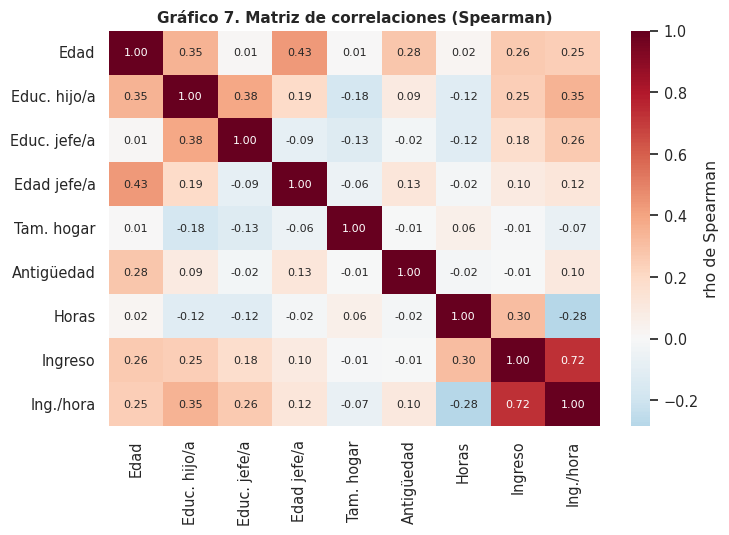

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
etiquetas = ["Edad", "Educ. hijo/a", "Educ. jefe/a", "Edad jefe/a", "Tam. hogar",
             "Antigüedad", "Horas", "Ingreso", "Ing./hora"]
m = final[NUM].corr(method="spearman")
m.index = m.columns = etiquetas
sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            annot_kws={"size": 8}, cbar_kws={"label": "rho de Spearman"})
ax.set_title("Gráfico 7. Matriz de correlaciones (Spearman)", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** La correlación más alta entre predictores es 0,43 (edad del hijo/a y del
jefe/a), por debajo del umbral que suele considerarse problemático: no se anticipan dificultades
graves de multicolinealidad en la regresión de la Fase 2. Llama la atención la correlación
**negativa** entre horas trabajadas e ingreso por hora (−0,28): quienes trabajan más horas ganan
menos por cada una, patrón característico de los empleos de baja calificación.

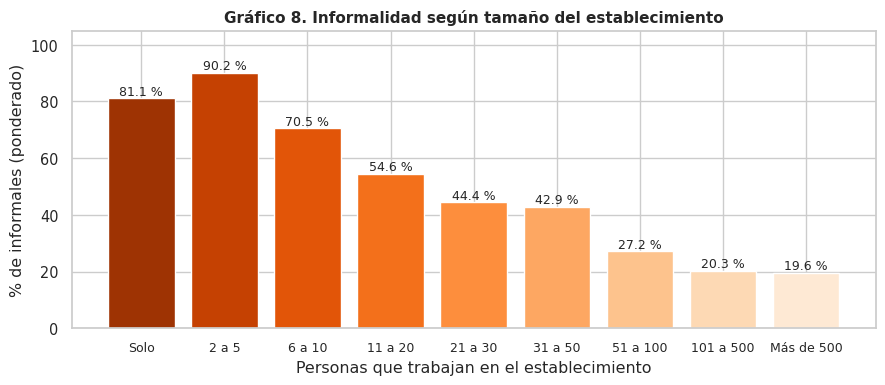

  Solo          81.1 %   (n = 554)
  2 a 5         90.2 %   (n = 1544)
  6 a 10        70.5 %   (n = 529)
  11 a 20       54.6 %   (n = 318)
  21 a 30       44.4 %   (n = 165)
  31 a 50       42.9 %   (n = 176)
  51 a 100      27.2 %   (n = 221)
  101 a 500     20.3 %   (n = 220)
  Más de 500    19.6 %   (n = 83)

Máximo: 90.2 % en «2 a 5»
Mínimo: 19.6 % en «Más de 500»
Amplitud: 70.6 puntos porcentuales
Excluida del gráfico — Trabajo doméstico: 99.2 % (n = 293)
Excluida del gráfico — No sabe: 41.7 % (n = 377)


In [ ]:
# Se grafican los nueve tramos de tamaño, excluyendo las categorías 10 (trabajo
# doméstico) y 11 (no sabe), que no expresan un tamaño de establecimiento
TRAMOS = {1: "Solo", 2: "2 a 5", 3: "6 a 10", 4: "11 a 20", 5: "21 a 30",
          6: "31 a 50", 7: "51 a 100", 8: "101 a 500", 9: "Más de 500"}

t = final[final.tam_empresa.isin(TRAMOS)]
vals = [W(t[t.tam_empresa == x]) * 100 for x in TRAMOS]
enes = [len(t[t.tam_empresa == x]) for x in TRAMOS]

fig, ax = plt.subplots(figsize=(9, 4))
b = ax.bar(range(len(TRAMOS)), vals, color=sns.color_palette("Oranges_r", len(TRAMOS)))
ax.bar_label(b, fmt="%.1f %%", fontsize=9)
ax.set_xticks(range(len(TRAMOS))); ax.set_xticklabels(list(TRAMOS.values()), fontsize=9)
ax.set_ylim(0, 105); ax.set_ylabel("% de informales (ponderado)")
ax.set_xlabel("Personas que trabajan en el establecimiento")
ax.set_title("Gráfico 8. Informalidad según tamaño del establecimiento",
             fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

for etiqueta, valor, ene in zip(TRAMOS.values(), vals, enes):
    print(f"  {etiqueta:12s} {valor:5.1f} %   (n = {ene})")
print("")
print(f"Máximo: {max(vals):.1f} % en «{list(TRAMOS.values())[vals.index(max(vals))]}»")
print(f"Mínimo: {min(vals):.1f} % en «{list(TRAMOS.values())[vals.index(min(vals))]}»")
print(f"Amplitud: {max(vals) - min(vals):.1f} puntos porcentuales")

# Categorías excluidas del gráfico, informadas por transparencia
for cod, nombre in [(10, "Trabajo doméstico"), (11, "No sabe")]:
    sub = final[final.tam_empresa == cod]
    if len(sub):
        print(f"Excluida del gráfico — {nombre}: {W(sub)*100:.1f} % (n = {len(sub)})")

**Interpretación.** La relación es fuerte pero **no es monótona**. El máximo no está en quienes
trabajan solos (81,1 %) sino en las microempresas de 2 a 5 personas (90,2 %); a partir de ahí el
descenso sí es sostenido, hasta 19,6 % en establecimientos de más de 500 personas. La amplitud
total supera los 70 puntos porcentuales.

Que el trabajo por cuenta propia tenga 9 puntos menos de informalidad que las microempresas es un
hallazgo en sí mismo: sugiere que entre quienes trabajan solos convive un grupo de independientes
formalizados —profesionales y oficios registrados que aportan a una caja— con el grueso del
trabajo precario, mientras que la microempresa de 2 a 5 personas es el ámbito donde la
informalidad es casi la norma.

Con una V de Cramér de 0,527, esta es con amplio margen **la variable más asociada a la
informalidad de todo el conjunto**, muy por encima de cualquier característica del hogar de
origen. Se informan además las dos categorías excluidas del gráfico por no expresar un tamaño de
establecimiento: el trabajo doméstico, con una informalidad prácticamente total, y los casos sin
dato.

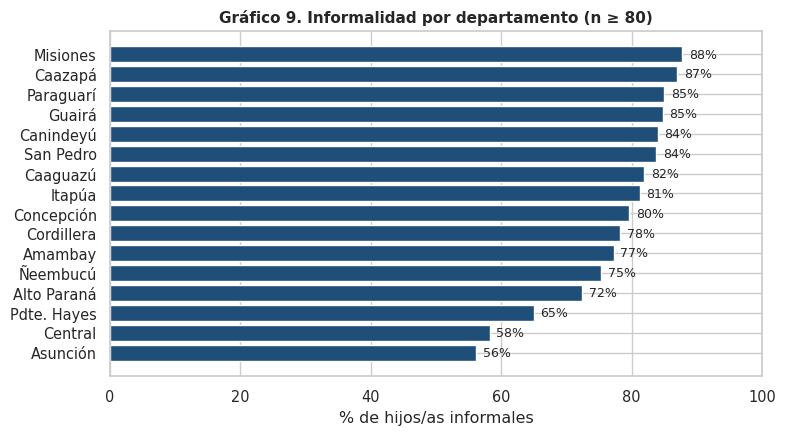

,tasa,n
departamento,,
Asunción,56.2,461.0
Central,58.3,1241.0
Pdte. Hayes,65.0,171.0
Alto Paraná,72.4,610.0
Ñeembucú,75.4,118.0
Amambay,77.3,182.0
Cordillera,78.3,230.0
Concepción,79.7,124.0
Itapúa,81.3,254.0


Amplitud entre extremos: 31.6 puntos porcentuales


In [ ]:
dp = final.groupby("departamento").apply(
    lambda x: pd.Series({"tasa": W(x) * 100, "n": len(x)}))
dp = dp[dp.n >= 80].sort_values("tasa")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(dp.index, dp.tasa, color=AZUL)
for i, t_ in enumerate(dp.tasa):
    ax.text(t_ + 1, i, f"{t_:.0f}%", va="center", fontsize=9)
ax.set_xlim(0, 100); ax.set_xlabel("% de hijos/as informales")
ax.set_title("Gráfico 9. Informalidad por departamento (n ≥ 80)", fontsize=11, weight="bold")
plt.tight_layout(); plt.show()

display(dp.round(1))
print(f"Amplitud entre extremos: {dp.tasa.max() - dp.tasa.min():.1f} puntos porcentuales")

**Interpretación.** La dispersión territorial supera los 30 puntos porcentuales entre extremos.
Asunción y Central presentan las tasas más bajas, coherente con la concentración de empleo formal
en el área metropolitana. Se excluyen los departamentos con menos de 80 casos porque el diseño
muestral de la EPHC no garantiza precisión a ese nivel de desagregación.

## 5.1. Patrones y anomalías identificados

**Patrón 1 — El tamaño del establecimiento domina sobre el origen familiar.** V de Cramér de
0,527 frente a 0,140 de la condición del jefe/a, con una amplitud de más de 70 puntos entre las
microempresas de 2 a 5 personas (90,2 %) y los establecimientos de más de 500 (19,6 %).
*Implicación:* cualquier modelo que omita esta variable atribuirá erróneamente al hogar un efecto
que corresponde al tipo de empleo.

**Patrón 2 — La educación del jefe/a discrimina más que su condición laboral.** Gradiente de
23,4 puntos frente a una brecha de 14,0. *Implicación:* el canal de transmisión podría ser
educativo antes que ocupacional.

**Patrón 3 — La informalidad juvenil es estructural, no coyuntural.** Diez trimestres sin
tendencia ni quiebre, con la media móvil siempre entre 66,0 % y 69,2 %.

**Anomalía 1 — El sexo no se asocia con la informalidad** (p = 0,590), pese a las conocidas
brechas de género en ingresos. Explicación plausible: la brecha opera sobre el **nivel de
remuneración** y no sobre la condición de formalidad.

**Anomalía 2 — La antigüedad casi no se relaciona con el ingreso** (rho = 0,083), contra lo que
predice la teoría del capital humano. En esta franja etaria la rotación es tan alta que la
permanencia no alcanza a traducirse en mejores remuneraciones.

## 5.2. Hipótesis para la Fase 2

| N.º | Hipótesis | Prueba prevista |
|---|---|---|
| H1 | La proporción de hijos/as informales difiere según la condición del jefe/a de hogar. | Chi-cuadrado con V de Cramér; prueba z de proporciones |
| H2 | La asociación se mantiene al controlar años de estudio propios, edad, sexo y área. | Regresión logística múltiple |
| H3 | El ingreso mediano de los informales es menor, incluso medido por hora trabajada. | U de Mann-Whitney con tamaño del efecto |
| H4 | La proporción de informales difiere entre los cuatro niveles educativos del jefe/a. | Chi-cuadrado con corrección por comparaciones múltiples |
| H5 | El tamaño del establecimiento se asocia con la informalidad con más intensidad que la condición del jefe/a. | Comparación de V de Cramér con intervalos por bootstrap |

Las cinco cubren tres familias distintas de pruebas, incorporan tamaño del efecto, contemplan
corrección por comparaciones múltiples y un intervalo estimado por bootstrap. **Todas admiten
resultado negativo**: si H2 no se sostuviera, la conclusión sería que lo que se transmite entre
generaciones es el nivel educativo y no la condición laboral, resultado igualmente válido y de
interés para la política pública.

## Limitación detectada para la Fase 2

Los pares provienen de menos hogares que casos, porque **hay hermanos en la muestra**: dos o más
hijos del mismo jefe/a, que comparten el mismo valor de la variable explicativa principal. No son
observaciones independientes entre sí.

La deduplicación aplicada resuelve las personas repetidas entre trimestres, no los hermanos
dentro de un mismo hogar. La corrección adecuada no es eliminarlos sino emplear **errores
estándar agrupados por hogar** en la regresión, técnica que corresponde a la Fase 2.

In [ ]:
print(f"Casos                            : {len(final):,}")
print(f"Hogares distintos                : {final.ID_HOGAR.nunique():,}")
print(f"Casos que comparten hogar con otro: {len(final) - final.ID_HOGAR.nunique():,}")
print(f"\nArchivos generados en {OUTPUT_DIR}:")
print("  dataset_limpio.csv · bitacora_limpieza.csv")

Casos                            : 4,480
Hogares distintos                : 3,642
Casos que comparten hogar con otro: 838

Archivos generados en /content/drive/MyDrive/datos_limpios:
  dataset_limpio.csv · bitacora_limpieza.csv


EXPORTACION A HTML

In [ ]:
from google.colab import files
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Fase1_Herencia_Informalidad.ipynb"
files.download("/content/drive/MyDrive/Colab Notebooks/Fase1_Herencia_Informalidad.html")

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Fase1_Herencia_Informalidad.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1215453 bytes to /content/drive/MyDrive/Colab Notebooks/Fase1_Herencia_Informalidad.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>